# Raman Spectrum Baseline Correction
This notebook processes Raman spectroscopy data step by step:
1. Load & fit the laser line
2. **Inspect the raw spectrum** → adjust cutoff if needed
3. **Tune ALS parameters** for photo- and RBM regions
4. **Inspect the baseline correction** → re-run step 3 if needed
5. Save the result

Each file is processed by running the numbered cells in order. After any plot cell you can go back, tweak the parameters, and re-run just that cell.

## 1. Imports

In [318]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from scipy.sparse.linalg import spsolve
from scipy import sparse
from scipy.linalg import cholesky
import string


## 2. Helper Functions

In [296]:

def gauss(x, A, mu, sigma, offset):
    """Gaussian function with offset."""
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2)) + offset


def gauss_fitter(x, y):
    """Fit a Gaussian to (x, y) data. Returns optimised parameters [A, mu, sigma, offset]."""
    p0 = [np.max(y), x[np.argmax(y)], 1, np.min(y)]
    popt, cov = curve_fit(gauss, x, y, p0=p0)
    return popt


def als(y, lam=1e6, p=0.1, itermax=10):
    r"""
    Asymmetric Least Squares Smoothing baseline correction.
    (P. Eilers, H. Boelens 2005)

    Parameters
    ----------
    y       : input spectrum / chromatogram
    lam     : smoothness parameter (larger = smoother baseline)
    p       : asymmetry weight; 0.5 = symmetric, <0.5 suppresses negative deviations
    itermax : number of iterations

    Returns
    -------
    z : fitted background vector
    """
    L = len(y)
    D = sparse.eye(L, format='csc')
    D = D[1:] - D[:-1]   # first difference
    D = D[1:] - D[:-1]   # second difference
    D = D.T
    w = np.ones(L)
    for i in range(itermax):
        W = sparse.diags(w, 0, shape=(L, L))
        Z = W + lam * D.dot(D.T)
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y < z)
    return z

## 3. Configuration

In [297]:
data_path = r"C:\Users\andre\ucloud\Documents\Samples"
sample    = "Lucius"
setup     = r'labRAM\v3'        # e.g. "LabRAM"
step      = 'dw'      # e.g. "S41"
laser     = '488'        # e.g. '633'

folder = os.path.join(data_path, sample, setup,'calibration')

# Per-laser low-wavenumber cutoffs  [488, 515, 568, 633]
cutoff_list = [140,140,140,140]#[100, 120, 150, 100]

# Override sample / folder for step S0
if step == 'S0':
    sample = "Ceasar"
    folder = os.path.join(data_path, sample, setup)

print(f"Folder : {folder}")
print(f"Step   : {step}  |  Laser: {laser}  |  Setup: {setup}")

Folder : C:\Users\andre\ucloud\Documents\Samples\Lucius\labRAM\v3\calibration
Step   : dw  |  Laser: 488  |  Setup: labRAM\v3


## 4. Discover Files

In [298]:
files = []
for (dirpath, dirnames, filenames) in os.walk(folder):
    files.extend(filenames)
    break  # top-level only

if step == 'S0':
    matching = [f for f in files if laser in f]
else:
    matching = [f for f in files if step in f and laser in f]
print(f"Found {len(matching)} matching file(s):")
for f in matching:
    print(" ", f)

Found 1 matching file(s):
  Lucius_dw_all_50x_gr1800_slit300_18A_488nm_spectromin80_30cycles_150s_COMBINED_CALIBRATED.csv


---
## 5. Select File
Set `file_index` to pick which file to process. Re-run this cell and all cells below for each new file.

In [299]:
file_index = 0   # <-- change this to process a different file

file = matching[file_index]
print(f"Selected: {file}")

# Select cutoff based on laser
cutoff_map = {'488': cutoff_list[0], '515': cutoff_list[1],
              '568': cutoff_list[2], '633': cutoff_list[3]}
cutoff = cutoff_map.get(laser, 100)
print(f"Cutoff  : {cutoff} cm⁻¹")

Selected: Lucius_dw_all_50x_gr1800_slit300_18A_488nm_spectromin80_30cycles_150s_COMBINED_CALIBRATED.csv
Cutoff  : 140 cm⁻¹


---
## 6. Load Data & Fit Laser Line

In [319]:
calibrated = True

# Load
df_file = pd.read_csv(os.path.join(folder, file), sep=',', header=None)
print(df_file)

# Normalise
df_file[1] = (df_file[1] - np.min(df_file[1])) / (np.max(df_file[1]) - np.min(df_file[1]))


if not calibrated:
    # Fit laser line and shift x-axis
    mask_laser = df_file[0] < 10
    gauss_params = gauss_fitter(df_file[0][mask_laser].values,
                                df_file[1][mask_laser].values)
    df_file[0] -= gauss_params[1]
    print(f"Laser line centre offset applied: {gauss_params[1]:.4f}")

    # Update / save laser-line parameters
    laser_params_dir  = folder.replace(setup, 'other')
    laser_params_path = os.path.join(laser_params_dir, 'laserline_params.csv')

    columns = ['Step', 'Laser', 'Setup', 'A', 'mu', 'sigma', 'offset']

    if not os.path.exists(laser_params_path):
        os.makedirs(laser_params_dir, exist_ok=True)
        laser_line_params = pd.DataFrame(columns=columns)
        laser_line_params.to_csv(laser_params_path, index=False)
        print(f"Created new laser line params file: {laser_params_path}")
    else:
        laser_line_params = pd.read_csv(laser_params_path, sep=',')

    already_exists = (
        step in laser_line_params['Step'].values and
        int(laser) in laser_line_params['Laser'].values and
        setup in laser_line_params['Setup'].values
    )

    if already_exists:
        print("Laser line parameters already exist — skipping write.")
    else:
        print(f"Adding laser line parameters for step={step}, laser={laser}, setup={setup}")
        new_row = pd.DataFrame(
            [[step, laser, setup, *gauss_params]],
            columns=columns
        )
        laser_line_params = pd.concat([laser_line_params, new_row], ignore_index=True)
        laser_line_params.to_csv(laser_params_path, index=False)

                0           1    2
0       76.151740  527.439392  rbm
1       76.795371  527.537598  rbm
2       77.437690  523.502563  rbm
3       78.081244  519.876953  rbm
4       78.724753  518.557068  rbm
...           ...         ...  ...
3067  3492.050948  281.032501   2d
3068  3493.551461  284.584320   2d
3069  3495.053681  277.972565   2d
3070  3496.553707  282.387268   2d
3071  3498.055441  277.972565   2d

[3072 rows x 3 columns]


---
## 7. Plot Raw Spectrum
Inspect the raw spectrum below. If the cutoff looks wrong, go back to **cell 5** and adjust `cutoff`, then re-run from there.

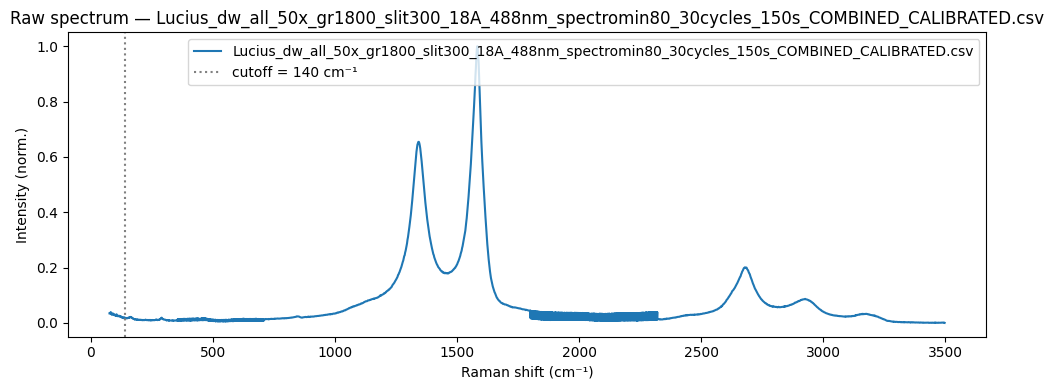

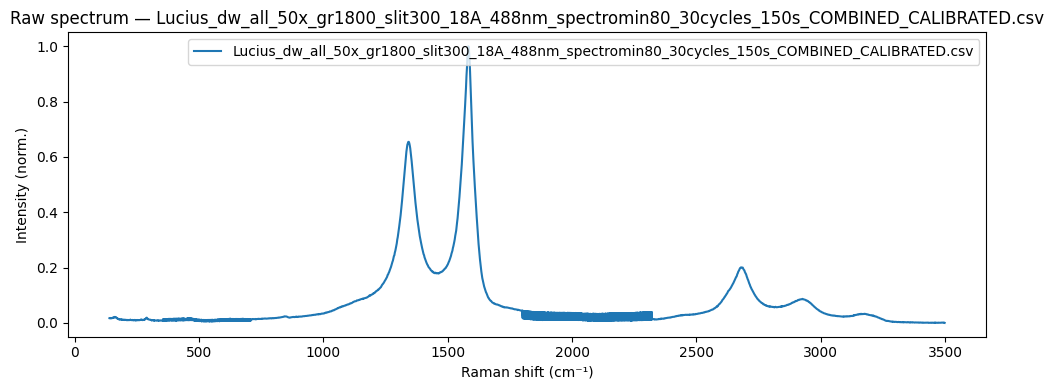

In [320]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_file[0], df_file[1], label=file)
ax.axvline(cutoff, color='gray', linestyle=':', label=f'cutoff = {cutoff} cm⁻¹')
ax.set_xlabel("Raman shift (cm⁻¹)")
ax.set_ylabel("Intensity (norm.)")
ax.set_title(f"Raw spectrum — {file}")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_file[0][df_file[0] > cutoff], df_file[1][df_file[0] > cutoff], label=file)
ax.set_xlabel("Raman shift (cm⁻¹)")
ax.set_ylabel("Intensity (norm.)")
ax.set_title(f"Raw spectrum — {file}")
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. ALS Parameters
Tune `asls_params_photo` and `asls_params_RBM` here, then run **cell 9** to see the result.  
Repeat until the baseline looks right — no need to re-run cells 5–7.

| Parameter | Effect |
|-----------|--------|
| `lam` | Larger → smoother baseline |
| `p` | Smaller → baseline hugs the bottom more aggressively |
| `itermax` | More iterations → finer convergence |

In [302]:
# asls_params = {
#     "RBM":  [50E2, 0.001,  10],
#     "D": [40E5,    0.0001,  10],
#     "G": [40E5,    0.0001,  10],
#     "2D":   [80E5,    0.0001,  10],
# }

# # Region boundaries in cm⁻¹ (adjust to match your spectrometer windows)
# regions = {
#     "RBM":  (cutoff, 1000),
#     "D":    (1000,  1400),
#     "G":    (1400,  1600),
#     "2D":   (2000,   np.inf),
# }

In [303]:
# --- Tune these parameters ---
# [lam, p, itermax] per region
asls_params = {
    "RBM":  [50E2, 0.001,  10],
    "DGCC": [40E5,    0.0001,  10],
    "2D":   [80E5,    0.0001,  10],
}

# Region boundaries in cm⁻¹ (adjust to match your spectrometer windows)
regions = {
    "RBM":  (cutoff, 400),
    "DGCC": (1000,   1900),
    "2D":   (2400,   np.inf),
}


---
## 9. Compute & Plot Baseline Correction
Re-run this cell after changing any ALS parameter in cell 8.

In [327]:


offset = 0.05  # vertical offset to separate original from corrected in the plots

# Re-normalise and trim
df_work = df_file.copy()
df_work[1] = (df_work[1] - np.min(df_work[1])) / (np.max(df_work[1]) - np.min(df_work[1]))
df_work = df_work[df_work[0] > cutoff].copy()

# ── Independent baseline correction per region ──
background = pd.Series(np.zeros(len(df_work)), index=df_work.index)

for name, (lo, hi) in regions.items():
    mask = (df_work[0] >= lo) & (df_work[0] < hi)
    if mask.sum() < 10:
        print(f"⚠️  {name}: no (or too few) data points in {lo}–{hi} cm⁻¹ — skipped")
        continue
    lam, p, itermax = asls_params[name]
    df_als = df_work[(df_work[2] == name.lower()) == True][1][mask]
    background[mask] = als(df_als, lam=lam, p=p, itermax=itermax)

corrected = df_work[1] - background

# ── Plots: one panel per region ──
fig, axes = plt.subplots(1, len(regions), figsize=(6 * len(regions), 5))

for ax, (name, (lo, hi)) in zip(axes, regions.items()):
    mask = (df_work[0] >= lo) & (df_work[0] < hi)
    if mask.sum() == 0:
        ax.set_title(f'{name} — no data')
        continue

    x = df_work[0][mask]
    ax.plot(x, df_work[1][mask] + offset,  label='Original',           color='steelblue')
    ax.plot(x, background[mask] + offset,  label='Background',         color='red', linestyle='--')
    ax.plot(x, corrected[mask],            label='Baseline corrected', color='green')
    ax.axhline(0, color='black', linewidth=0.6, linestyle=':')

    hi_label = f'{hi:g}' if np.isfinite(hi) else f'{x.max():.0f}'
    ax.set_xlabel('Raman shift (cm⁻¹)')
    ax.set_ylabel('Intensity (norm.)')
    ax.set_title(f'{name} region ({lo:g}–{hi_label} cm⁻¹)')
    ax.legend(fontsize=8)

    # small flatness indicator per region
    sigma = corrected[mask].std()
    ax.text(0.02, 0.97, f'σ = {sigma:.4f}', transform=ax.transAxes,
            fontsize=9, va='top', color='gray')

plt.suptitle(file, fontsize=11)
plt.tight_layout()
plt.show()

print('\nHappy with the result? Run cell 10 to save, or go back to cell 8 to adjust parameters.')

KeyError: 0

---
## 10. Save Result
Only run this cell when the baseline looks correct.

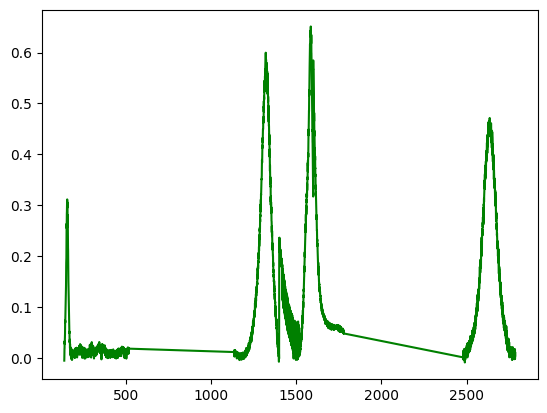

Saved spectrum  → C:\Users\andre\ucloud\Documents\Samples\Lucius\labRAM\calibration\Baseline_Corrected\Lucius_annealed_all_50x_gr1800_slit300_27A_568nm_spectro80_20cycles_60s_COMBINED_CALIBRATED_baseline_corrected.csv
Saved metadata  → C:\Users\andre\ucloud\Documents\Samples\Lucius\labRAM\calibration\Baseline_Corrected\als_metadata.csv


In [272]:
df_save = df_work.copy()
df_save[1] = corrected
# df_save[1] -= background[0]
df_save = df_save[df_save[0] < 2990]

plt.plot(df_save[0], df_save[1], label='Baseline corrected', color='green')
plt.show()

out_dir = os.path.join(folder, 'Baseline_Corrected')
os.makedirs(out_dir, exist_ok=True)

# Save baseline-corrected spectrum
out_path = os.path.join(out_dir, file.replace('.csv', '_baseline_corrected.csv'))
df_save.to_csv(out_path, sep='\t', header=False, index=False)
print(f"Saved spectrum  → {out_path}")

# Save / update metadata CSV with ALS parameters
meta_path = os.path.join(out_dir, 'als_metadata.csv')
meta_columns = [
    'filename',
    'step', 'laser', 'setup',
    'cutoff',
    'RBM_lam',   'RBM_p',   'RBM_itermax',
]

if os.path.exists(meta_path):
    metadata = pd.read_csv(meta_path)
else:
    metadata = pd.DataFrame(columns=meta_columns)

new_meta = pd.DataFrame([{
    'filename'          : os.path.basename(out_path),
    'step'              : step,
    'laser'             : laser,
    'setup'             : setup,
    'cutoff'            : cutoff,
    **{f'{name}_{key}': value for (name, params) in asls_params.items() for key, value in zip(['lam', 'p', 'itermax'], params)}
}])

# Overwrite row if this filename was already saved before
metadata = metadata[metadata['filename'] != new_meta['filename'].iloc[0]]
metadata = pd.concat([metadata, new_meta], ignore_index=True)
metadata.to_csv(meta_path, index=False)
print(f"Saved metadata  → {meta_path}")